## **Import Libraries**

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import classification_report, confusion_matrix



## **Data Preparation & Preprocessing**

 ### Creating DataFrames for Training and Testing Sets

In [3]:
train_dir = '/kaggle/input/sports-balls-multiclass-image-classification/train'

filepaths = []
labels = []

folds = os.listdir(train_dir)

for fold in folds:
    foldpath = os.path.join(train_dir, fold)
    
    files = os.listdir(foldpath)
    for f in files:
        fpath = os.path.join(foldpath, f)
        
        filepaths.append(fpath)
        labels.append(fold)
        
train_df = pd.DataFrame(data={'filepaths':filepaths, 'labels':labels})
train_df

,filepaths,labels
0,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
1,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
2,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
3,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
4,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
...,...,...
7323,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7324,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7325,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7326,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball


In [5]:
test_dir = '/kaggle/input/sports-balls-multiclass-image-classification/test'

filepaths = []
labels = []

folds = os.listdir(train_dir)

for fold in folds:
    foldpath = os.path.join(train_dir, fold)
    
    files = os.listdir(foldpath)
    for f in files:
        fpath = os.path.join(foldpath, f)
        
        filepaths.append(fpath)
        labels.append(fold)
        
tst_df = pd.DataFrame(data={'filepaths':filepaths, 'labels':labels})
tst_df

,filepaths,labels
0,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
1,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
2,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
3,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
4,/kaggle/input/sports-balls-multiclass-image-cl...,rugby_ball
...,...,...
7323,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7324,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7325,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball
7326,/kaggle/input/sports-balls-multiclass-image-cl...,tennis_ball


In [7]:
valid_df, test_df = train_test_split(tst_df, test_size=0.5, random_state=42,shuffle=True)

### Exploring Class Distribution with Sample Images

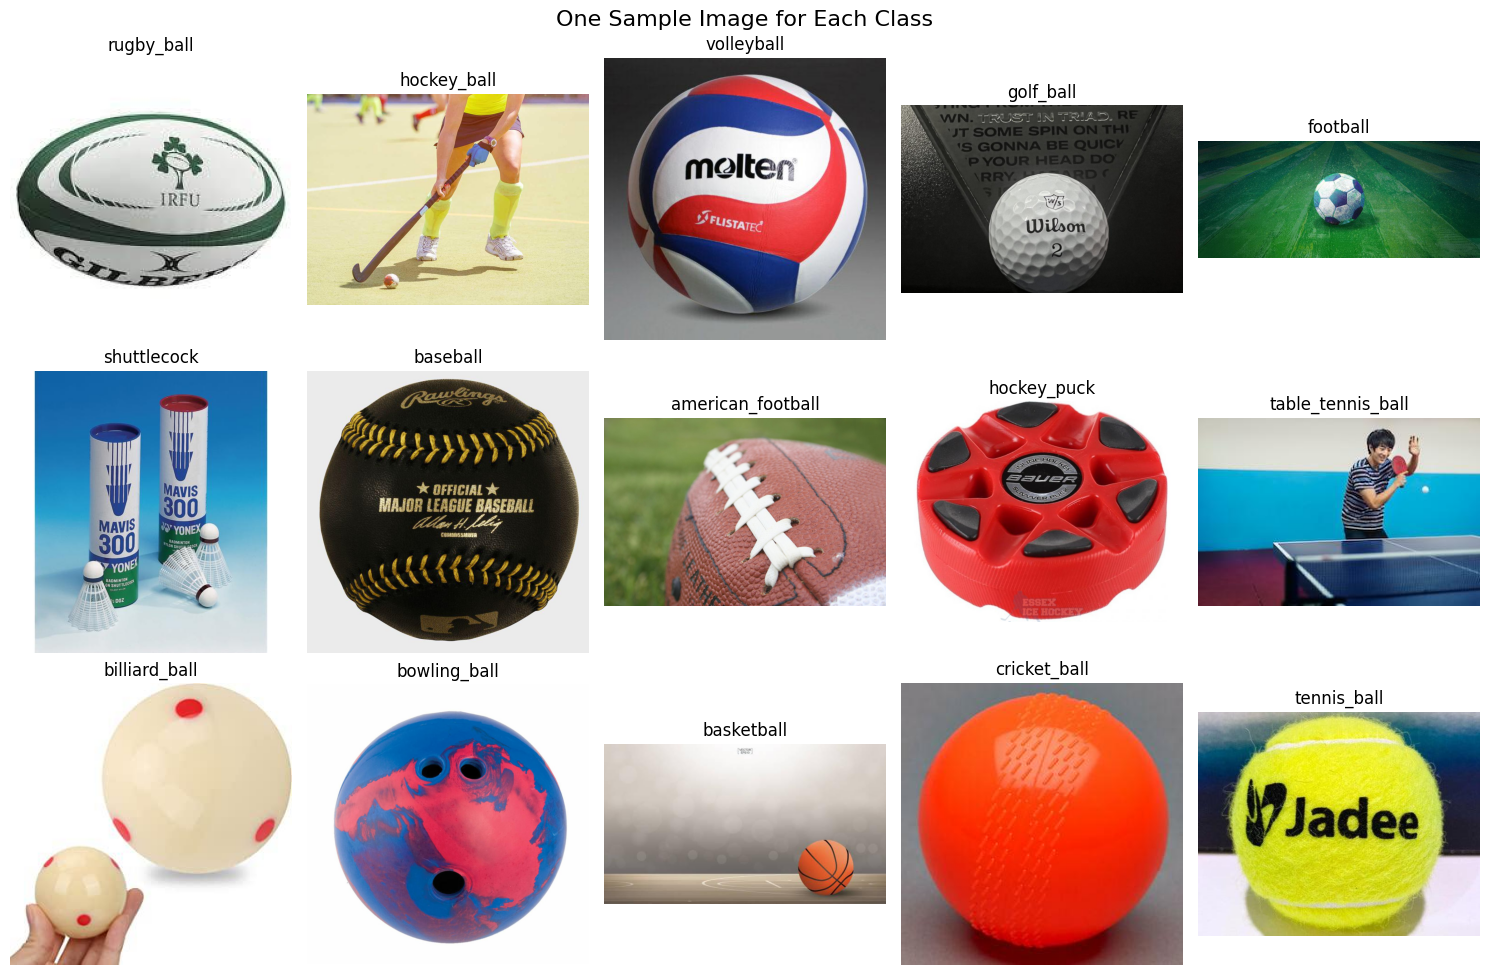

In [9]:

from PIL import Image

# Assuming train_df has 'filepath' and 'labels' columns
# Get a sample image for each class from train_df
sample_images = {}

# Loop through train_df to get one image per class
for index, row in train_df.iterrows():
    class_label = row['labels']
    if class_label not in sample_images:
        # Load the image and store it if this class is not yet in sample_images
        image = Image.open(row['filepaths'])
        sample_images[class_label] = image

    # Stop if we have one image for each class
    if len(sample_images) == 15:
        break

# Plot the sample images
fig, axes = plt.subplots(3, 5, figsize=(15, 10))  # Adjust grid size if needed
fig.suptitle('One Sample Image for Each Class', fontsize=16)

# Display each image with its class label
for idx, (class_label, image) in enumerate(sample_images.items()):
    ax = axes[idx // 5, idx % 5]  # Position in the grid
    ax.imshow(image)
    ax.axis("off")
    ax.set_title(class_label)

plt.tight_layout()
plt.show()


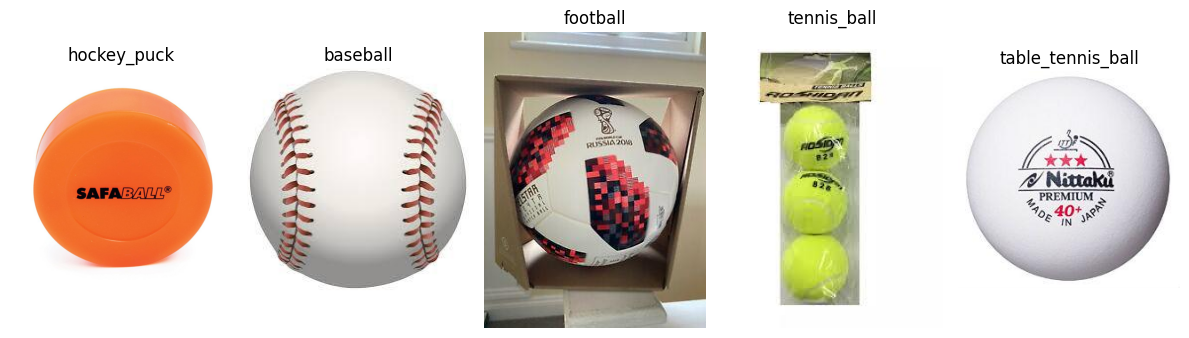

In [26]:
 #Display some sample images from the DataFrame
def display_sample_images(dataframe, n=5):
    plt.figure(figsize=(12, 12))
    
    # Select n random samples from the dataframe
    sample_df = dataframe.sample(n=n).reset_index(drop=True)
    
    for i in range(n):
        filepath = sample_df.loc[i, 'filepaths']
        label = sample_df.loc[i, 'labels']
        
        # Read and display the image
        image = cv2.imread(filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for correct color display
        
        plt.subplot(1, n, i+1)
        plt.imshow(image)
        plt.title(label, fontsize=12)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Call the function with the dataframe
display_sample_images(train_df, n=5)

### Creating Data Generators with Augmentation

In [18]:
tr_gen = ImageDataGenerator(rotation_range=0.45,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.4,
                            horizontal_flip=True,
                            vertical_flip=True)

ts_gen = ImageDataGenerator(rotation_range=0.45,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.4,
                            horizontal_flip=True,
                            vertical_flip=True)

train_gen = tr_gen.flow_from_dataframe(train_df,
                                       x_col='filepaths',
                                       y_col='labels',
                                       target_size=(224, 224),
                                       color_mode='rgb',
                                       class_mode='categorical' ,
                                       batch_size=32)

test_gen = ts_gen.flow_from_dataframe(test_df,
                                      x_col='filepaths',
                                      y_col='labels',
                                      target_size=(224, 224),
                                      color_mode='rgb',
                                      class_mode='categorical' ,
                                      batch_size=32)

val_gen = ImageDataGenerator(rotation_range=0.45,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            zoom_range=0.4,
                            horizontal_flip=True,
                            vertical_flip=True)

valid_gen = val_gen.flow_from_dataframe(valid_df,
                                      x_col='filepaths',
                                      y_col='labels',
                                      target_size=(224, 224),
                                      color_mode='rgb',
                                      class_mode='categorical' ,
                                      batch_size=32)

Found 7328 validated image filenames belonging to 15 classes.
Found 3664 validated image filenames belonging to 15 classes.
Found 3664 validated image filenames belonging to 15 classes.


## **Building the Deep Learning Model**

### Creating a Sequential Model with EfficientNetB3 as Base

In [19]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    input_shape=None,
    pooling=None,
    classes=1000,
    classifier_activation="softmax",
    
)

model = Sequential([
    base_model,
    Flatten(),
    
    
    Dense(256,activation='relu'),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(32,activation='relu'),
    Dense(15,activation='softmax'),
])

model.compile(optimizer=Adamax(learning_rate=0.001),loss='categorical_crossentropy', metrics=['accuracy'])

In [20]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ ?                      │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,783,535 (41.14 MB)

 Trainable params: 10,696,232 (40.80 MB)

 Non-trainable params: 87,303 (341.03 KB)

In [21]:
history = model.fit(train_gen, validation_data = valid_gen, epochs=20)

Epoch 1/20


/opt/conda/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


229/229 ━━━━━━━━━━━━━━━━━━━━ 281s 672ms/step - accuracy: 0.4442 - loss: 1.8517 - val_accuracy: 0.8316 - val_loss: 0.5978
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 605ms/step - accuracy: 0.8045 - loss: 0.6827 - val_accuracy: 0.9001 - val_loss: 0.3378
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 603ms/step - accuracy: 0.8592 - loss: 0.4853 - val_accuracy: 0.9419 - val_loss: 0.1984
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 605ms/step - accuracy: 0.8998 - loss: 0.3457 - val_accuracy: 0.9427 - val_loss: 0.1864
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 142s 607ms/step - accuracy: 0.9177 - loss: 0.2865 - val_accuracy: 0.9626 - val_loss: 0.1272
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 602ms/step - accuracy: 0.9297 - loss: 0.2333 - val_accuracy: 0.9651 - val_loss: 0.1127
Epoch 7/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 604ms/step - accuracy: 0.9340 - loss: 0.2300 - val_accuracy: 0.9626 - val_loss: 0.1230
Epoch 8/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 141s 603ms/step - accuracy: 0.9452 - loss: 0.18

### Model Evaluation Results

In [22]:
train_score = model.evaluate(train_gen)
valid_score = model.evaluate(valid_gen)
test_score = model.evaluate(test_gen)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

229/229 ━━━━━━━━━━━━━━━━━━━━ 92s 400ms/step - accuracy: 0.9933 - loss: 0.0194
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 398ms/step - accuracy: 0.9949 - loss: 0.0207
115/115 ━━━━━━━━━━━━━━━━━━━━ 46s 398ms/step - accuracy: 0.9968 - loss: 0.0143
Train Loss:  0.02044357731938362
Train Accuracy:  0.9939956068992615
--------------------
Validation Loss:  0.01954534277319908
Validation Accuracy:  0.9945414662361145
--------------------
Test Loss:  0.013083676807582378
Test Accuracy:  0.9967249035835266


### Model Summary

In [23]:
results_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Loss": [train_score[0], valid_score[0], test_score[0]],
    "Accuracy": [train_score[1], valid_score[1], test_score[1]]
})

results_df

,Dataset,Loss,Accuracy
0,Train,0.020444,0.993996
1,Validation,0.019545,0.994541
2,Test,0.013084,0.996725
